In [7]:
import os
import gc
import json
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.utils import resample
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.metrics import Recall, Precision
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix, precision_score
# --- CONFIGURAÇÕES --
PASTAS_DATASET = [
    'imagens_acrais_benignas',
    'imagens_acrais_maligno'
]

CAMINHO_MODELOS = 'Modelos'



In [8]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Permite que o TF aloque memória gradualmente conforme a necessidade
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(f"Erro na config da GPU: {e}")

In [9]:
# Definir Presets
TAMANHO_IMAGEM = (224, 224)

# CARREGAR E COMBINAR METADADOS ---
dfs = []
for pasta in PASTAS_DATASET:
    caminho_csv = os.path.join(pasta, 'metadata.csv')
    if os.path.exists(caminho_csv):
        df_temp = pd.read_csv(caminho_csv)
        # Cria uma nova coluna com o caminho completo da imagem para facilitar
        df_temp['caminho_imagem'] = df_temp['isic_id'].apply(lambda x: os.path.join(pasta, f"{x}.jpg"))
        dfs.append(df_temp)
    else:
        print(f"Aviso: {caminho_csv} não encontrado.")

# Junta os CSVs das duas pastas em um só DataFrame
df_completo = pd.concat(dfs, ignore_index=True)

# FILTRAR DATASET (Usando todas as imagens disponíveis) ---
## 1. Primeiro, removemos duplicatas baseadas no ID único e verificamos existência física
df_unico = df_completo.drop_duplicates(subset='isic_id')
df_existente = df_unico[df_unico['caminho_imagem'].apply(os.path.exists)].copy()

## 2. Separar as classes sem limite de amostras
df_benigno = df_existente[df_existente['diagnosis_1'] == 'Benign']
df_maligno = df_existente[df_existente['diagnosis_1'] == 'Malignant']

## 3. Combinar e embaralhar o dataset final com tudo que foi encontrado
df_filtrado = pd.concat([df_benigno, df_maligno]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset total criado com {len(df_filtrado)} imagens (Benignas: {len(df_benigno)}, Malignas: {len(df_maligno)}).")

Dataset total criado com 2059 imagens (Benignas: 1557, Malignas: 502).


In [10]:
print("=== DADOS: VALIDAÇÃO (20% do df_filtrado) + TREINO EQUILIBRADO (oversampling) ===")

TAMANHO_B0 = (224, 224)
BATCH_SIZE = 32

# Validação: 20% do df_filtrado, sem augmentation (métricas mais estáveis)
datagen_val = ImageDataGenerator(validation_split=0.2)
val_gen = datagen_val.flow_from_dataframe(
    dataframe=df_filtrado,
    x_col="caminho_imagem",
    y_col="diagnosis_1",
    target_size=TAMANHO_B0,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False,
)

# Oversampling da classe minoritária até igualar a majoritária
df_malignant = df_filtrado[df_filtrado["diagnosis_1"] == "Malignant"]
df_benign = df_filtrado[df_filtrado["diagnosis_1"] == "Benign"]
maior_classe = max(len(df_malignant), len(df_benign))
df_benign_upsampled = resample(
    df_benign, replace=True, n_samples=maior_classe, random_state=42
)
df_malignant_upsampled = resample(
    df_malignant, replace=True, n_samples=maior_classe, random_state=42
)
df_equilibrado = pd.concat([df_malignant_upsampled, df_benign_upsampled]).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print(f"Treino equilibrado: {len(df_equilibrado)} imagens")
print(df_equilibrado["diagnosis_1"].value_counts())

datagen_balanced = ImageDataGenerator(
    validation_split=0.2,
    rotation_range=45,       # Rotação padrão (o artigo não especifica 360, então usamos um valor moderado comum)
    width_shift_range=0.1,   # Translações horizontais
    height_shift_range=0.1,  # Translações verticais
    horizontal_flip=True,    # Flips aleatórios
    vertical_flip=True       # Flips aleatórios
    # Sem zoom, sem alteração de cor, sem shear.
)

train_gen_balanced = datagen_balanced.flow_from_dataframe(
    dataframe=df_equilibrado,
    x_col="caminho_imagem",
    y_col="diagnosis_1",
    target_size=TAMANHO_B0,
    batch_size=BATCH_SIZE,
    class_mode="binary",
)

=== DADOS: VALIDAÇÃO (20% do df_filtrado) + TREINO EQUILIBRADO (oversampling) ===
Found 411 validated image filenames belonging to 2 classes.


Treino equilibrado: 3114 imagens
diagnosis_1
Malignant    1557
Benign       1557
Name: count, dtype: int64
Found 3114 validated image filenames belonging to 2 classes.


In [11]:
# 1. Definindo a grade de testes (3 LRs x 2 Dropouts = 6 Testes)
# learning_rates = [1e-3, 1e-4, 1e-5] 
learning_rates = [1e-4, 1e-5] 
dropouts = [0.4, 0.5]               

# Dicionário para salvar os históricos na memória (útil para a sua próxima célula)
historicos_grid = {}

print("=== INICIANDO GRID SEARCH (6 TESTES) ===")

# O Looping Duplo
for lr in learning_rates:
    for do in dropouts:
        
        # Nome formatado para o teste atual (Ex: LR1e-04_DO0.4)
        nome_teste = f"{CAMINHO_MODELOS}/LR{lr}_DO{do}"
        nome_arquivo = f"{CAMINHO_MODELOS}/treino_{nome_teste}.keras"
        
        print(f"\n" + "="*60)
        print(f"INICIANDO TESTE: {nome_teste}")
        print(f"Taxa de Aprendizado: {lr} | Dropout: {do}")
        print("="*60)
        
        # === PASSO CRÍTICO: LIMPAR MEMÓRIA DA GPU ===
        # Se não fizer isso, a GPU vai travar no 3º ou 4º teste.
        tf.keras.backend.clear_session()
        gc.collect()
        
        # === MONTANDO A REDE DO ZERO PARA ESTE TESTE ===
        base_model = EfficientNetB0(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )
        base_model.trainable = True # Full Fine-Tuning ativado
        
        x = base_model.output
        x = GlobalAveragePooling2D()(x)
        x = Dropout(do)(x) # Usando o valor de Dropout do Loop
        saida = Dense(1, activation="sigmoid")(x)
        modelo_cnn = Model(inputs=base_model.input, outputs=saida)
        
        # === COMPILANDO ===
        modelo_cnn.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr), # Usando o LR do Loop
            loss="binary_crossentropy",
            metrics=["accuracy", tf.keras.metrics.Recall(name="recall")],
        )
        
        # === CALLBACKS DINÂMICOS ===
        callbacks_lista = [
            EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
            ModelCheckpoint(
                filepath=nome_arquivo, # Salva o arquivo com o nome customizado!
                monitor='val_recall',                 
                mode='max',                           
                save_best_only=True,                  
                verbose=1
            ),
            ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=0)
        ]
        
        # === TREINAMENTO ===
        print(f"Treinando modelo {nome_teste}...")
        history = modelo_cnn.fit(
            train_gen_balanced,
            validation_data=val_gen,
            epochs=20, # Reduzi levemente as épocas máximas já que são 6 testes, o EarlyStop para antes se precisar
            callbacks=callbacks_lista,
            verbose=1 # Mantenha 1 para acompanhar o progresso, ou mude para 0 se quiser o terminal limpo
        )
        
        # Salva o histórico de métricas no dicionário
        historicos_grid[nome_teste] = history.history

print("\n✅ GRID SEARCH CONCLUÍDO COM SUCESSO!")
print("Os 6 arquivos .keras foram salvos no seu diretório.")

=== INICIANDO GRID SEARCH (6 TESTES) ===

INICIANDO TESTE: Modelos/LR0.0001_DO0.4
Taxa de Aprendizado: 0.0001 | Dropout: 0.4
Treinando modelo Modelos/LR0.0001_DO0.4...
Epoch 1/20


W0000 00:00:1778076457.234201   10772 cpu_allocator_impl.cc:82] Allocation of 19267584 exceeds 10% of free system memory.
W0000 00:00:1778076458.506270   10771 cpu_allocator_impl.cc:82] Allocation of 19267584 exceeds 10% of free system memory.


 2/98 ━━━━━━━━━━━━━━━━━━━━ 23s 247ms/step - accuracy: 0.5547 - loss: 0.7160 - recall: 0.5778   

W0000 00:00:1778076510.978715   10772 cpu_allocator_impl.cc:82] Allocation of 19267584 exceeds 10% of free system memory.


29/98 ━━━━━━━━━━━━━━━━━━━━ 1:05 954ms/step - accuracy: 0.6942 - loss: 0.5883 - recall: 0.7174

E0000 00:00:1778076559.386507    8984 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778076561.252857    8984 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778076566.486461    8984 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778076574.368082    8984 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778076581.760132    8984 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7912 - loss: 0.4403 - recall: 0.8159

E0000 00:00:1778076737.436754    8981 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778076739.407342    8981 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778076740.418704    8981 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778076742.958682    8981 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_recall improved from None to 0.77551, saving model to Modelos/treino_Modelos/LR0.0001_DO0.4.keras

Epoch 1: finished saving model to Modelos/treino_Modelos/LR0.0001_DO0.4.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 349s 3s/step - accuracy: 0.8651 - loss: 0.3139 - recall: 0.8857 - val_accuracy: 0.9124 - val_loss: 0.1897 - val_recall: 0.7755 - learning_rate: 1.0000e-04
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 958ms/step - accuracy: 0.9422 - loss: 0.1514 - recall: 0.9569
Epoch 2: val_recall improved from 0.77551 to 0.97959, saving model to Modelos/treino_Modelos/LR0.0001_DO0.4.keras

Epoch 2: finished saving model to Modelos/treino_Modelos/LR0.0001_DO0.4.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.9457 - loss: 0.1448 - recall: 0.9583 - val_accuracy: 0.9611 - val_loss: 0.0932 - val_recall: 0.9796 - learning_rate: 1.0000e-04
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9684 - loss: 0.0985 - recall: 0.9747   
Epoch 3: val_recall did not improve from 0.979

=== AVALIAÇÃO DOS MODELOS (GRID SEARCH) ===

📊 AVALIANDO MODELO: LR0.001_DO0.4

Relatório de Classificação (LR0.001_DO0.4):
              precision    recall  f1-score   support

      Benign     1.0000    0.9936    0.9968       313
   Malignant     0.9800    1.0000    0.9899        98

    accuracy                         0.9951       411
   macro avg     0.9900    0.9968    0.9933       411
weighted avg     0.9952    0.9951    0.9952       411



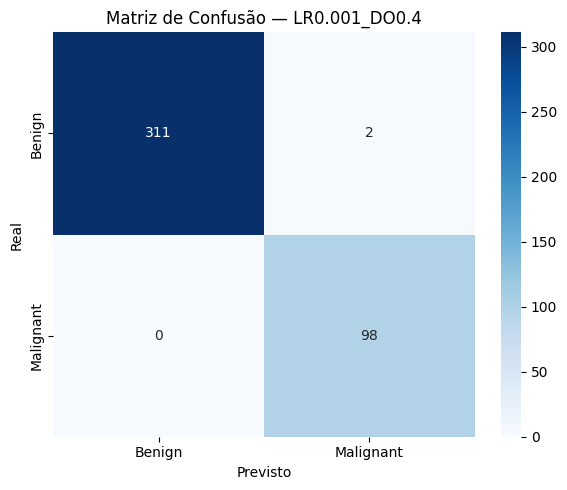


📊 AVALIANDO MODELO: LR0.001_DO0.5

Relatório de Classificação (LR0.001_DO0.5):
              precision    recall  f1-score   support

      Benign     1.0000    0.9872    0.9936       313
   Malignant     0.9608    1.0000    0.9800        98

    accuracy                         0.9903       411
   macro avg     0.9804    0.9936    0.9868       411
weighted avg     0.9906    0.9903    0.9903       411



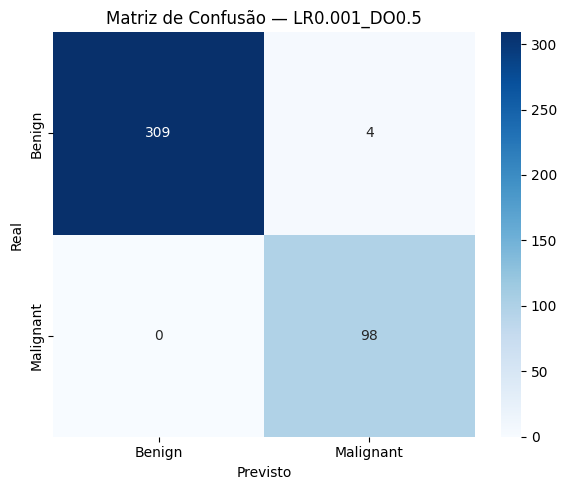


📊 AVALIANDO MODELO: LR0.0001_DO0.4

Relatório de Classificação (LR0.0001_DO0.4):
              precision    recall  f1-score   support

      Benign     1.0000    0.9936    0.9968       313
   Malignant     0.9800    1.0000    0.9899        98

    accuracy                         0.9951       411
   macro avg     0.9900    0.9968    0.9933       411
weighted avg     0.9952    0.9951    0.9952       411



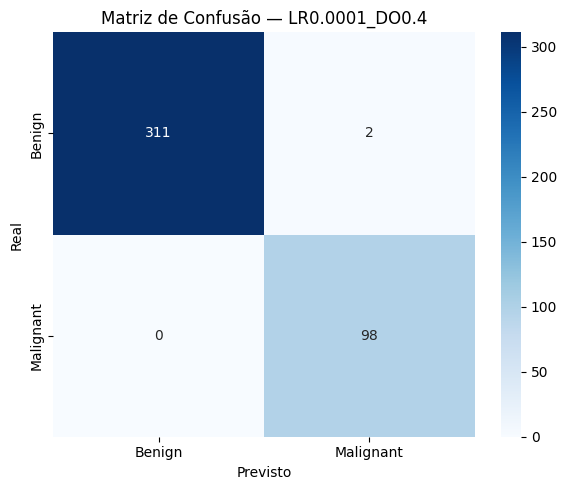


📊 AVALIANDO MODELO: LR0.0001_DO0.5

Relatório de Classificação (LR0.0001_DO0.5):
              precision    recall  f1-score   support

      Benign     1.0000    1.0000    1.0000       313
   Malignant     1.0000    1.0000    1.0000        98

    accuracy                         1.0000       411
   macro avg     1.0000    1.0000    1.0000       411
weighted avg     1.0000    1.0000    1.0000       411



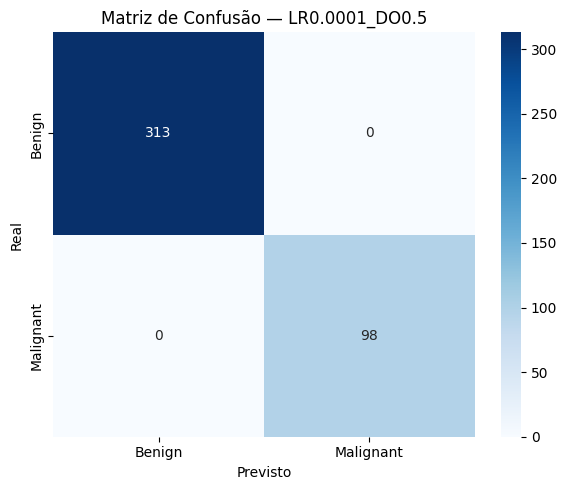


📊 AVALIANDO MODELO: LR1e-05_DO0.4

Relatório de Classificação (LR1e-05_DO0.4):
              precision    recall  f1-score   support

      Benign     1.0000    0.9233    0.9601       313
   Malignant     0.8033    1.0000    0.8909        98

    accuracy                         0.9416       411
   macro avg     0.9016    0.9617    0.9255       411
weighted avg     0.9531    0.9416    0.9436       411



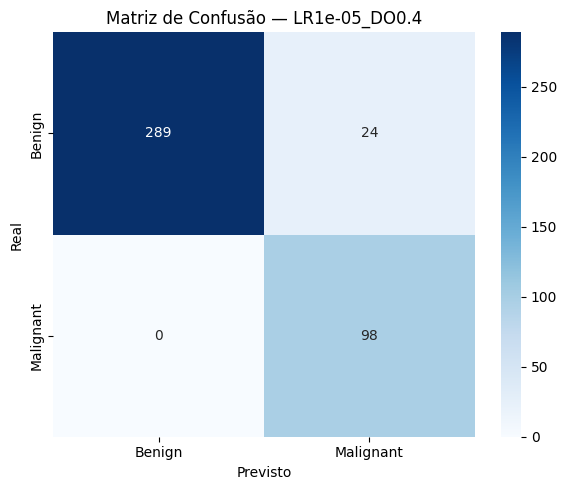


📊 AVALIANDO MODELO: LR1e-05_DO0.5

Relatório de Classificação (LR1e-05_DO0.5):
              precision    recall  f1-score   support

      Benign     0.9965    0.9042    0.9481       313
   Malignant     0.7638    0.9898    0.8622        98

    accuracy                         0.9246       411
   macro avg     0.8801    0.9470    0.9051       411
weighted avg     0.9410    0.9246    0.9276       411



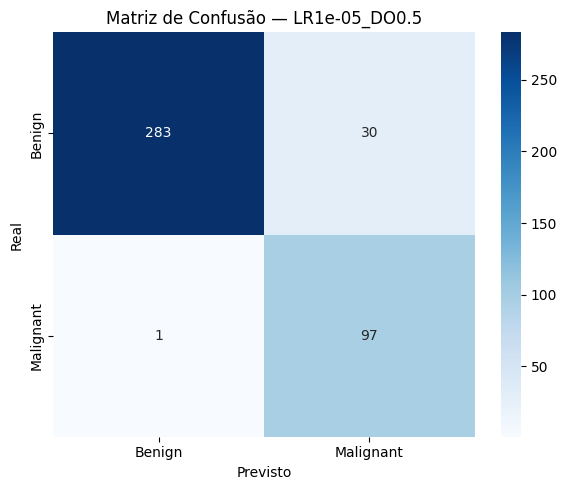

In [12]:
import os
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import gc

learning_rates = [1e-3, 1e-4, 1e-5] 
dropouts = [0.4, 0.5]

print("=== AVALIAÇÃO DOS MODELOS (GRID SEARCH) ===")

y_true = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

# Define a pasta onde você salvou (ajuste se for diferente)
pasta_modelos = "Modelos/treino_Modelos" # Ou "Modelos_TCC", dependendo de como você nomeou

for lr in learning_rates:
    for do in dropouts:
        nome_teste = f"LR{lr}_DO{do}"
        nome_arquivo = f"{nome_teste}.keras"
        
        # O os.path.join coloca a barra '/' automaticamente e do jeito certo
        caminho_completo = os.path.join(pasta_modelos, nome_arquivo)
        
        print(f"\n" + "="*60)
        print(f"📊 AVALIANDO MODELO: {nome_teste}")
        print("="*60)
        
        try:
            # 1. Carrega o modelo treinado
            modelo_salvo = tf.keras.models.load_model(caminho_completo)
            
            # 2. Resetar o gerador de validação
            val_gen.reset()
            
            # 3. Fazer predições
            y_prob = modelo_salvo.predict(val_gen, verbose=0).flatten()
            y_pred = (y_prob > 0.5).astype(int)
            
            # 4. Relatório
            print(f"\nRelatório de Classificação ({nome_teste}):")
            print(classification_report(y_true, y_pred, target_names=class_labels, digits=4, zero_division=0))
            
            # 5. Matriz de Confusão
            cm = confusion_matrix(y_true, y_pred)
            plt.figure(figsize=(6, 5))
            sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
            plt.title(f"Matriz de Confusão — {nome_teste}")
            plt.ylabel("Real")
            plt.xlabel("Previsto")
            plt.tight_layout()
            plt.show()
            
            # 6. Limpar memória
            del modelo_salvo
            tf.keras.backend.clear_session()
            gc.collect()
            
        except (FileNotFoundError, ValueError): # Agora ele captura o ValueError do Keras 3!
            print(f"⚠️ Arquivo {caminho_completo} não encontrado. Ele pode não ter salvo corretamente ou o treino foi interrompido.")

In [ ]:
# === PREPARAÇÃO DO DATASET DE TESTE: ISIC-images ===
print("=== PREPARANDO DATASET DE TESTE: ISIC-images ===\n")

PASTA_ISIC = 'ISIC-images'

# Carrega os metadados do dataset ISIC-images
df_isic = pd.read_csv(os.path.join(PASTA_ISIC, 'metadata.csv'))

# Cria coluna com o caminho completo de cada imagem
df_isic['caminho_imagem'] = df_isic['isic_id'].apply(
    lambda x: os.path.join(PASTA_ISIC, f"{x}.jpg")
)

# Remove duplicatas por isic_id
df_isic = df_isic.drop_duplicates(subset='isic_id')

# Verifica existência física das imagens no disco
df_isic = df_isic[df_isic['caminho_imagem'].apply(os.path.exists)].copy()

# Filtra apenas as classes de interesse (Benign e Malignant)
df_isic_filtrado = df_isic[df_isic['diagnosis_1'].isin(['Benign', 'Malignant'])].copy()
df_isic_filtrado = df_isic_filtrado.reset_index(drop=True)

# Estatísticas do dataset organizado
n_total    = len(df_isic_filtrado)
n_benign   = len(df_isic_filtrado[df_isic_filtrado['diagnosis_1'] == 'Benign'])
n_malignant = len(df_isic_filtrado[df_isic_filtrado['diagnosis_1'] == 'Malignant'])

print(f"Dataset ISIC-images organizado com sucesso!")
print(f"  Total de imagens : {n_total}")
print(f"  Benignas         : {n_benign}")
print(f"  Malignas         : {n_malignant}")
print(f"\nDistribuição das classes:")
print(df_isic_filtrado['diagnosis_1'].value_counts())


In [ ]:
# === TESTE DOS 6 MODELOS NO DATASET ISIC-IMAGES + MATRIZES DE CONFUSÃO ===
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

TAMANHO_B0   = (224, 224)
BATCH_SIZE   = 32
PASTA_MODELOS = "Modelos/treino_Modelos"

learning_rates = [1e-3, 1e-4, 1e-5]
dropouts       = [0.4, 0.5]

print("=== TESTANDO OS 6 MODELOS NO DATASET ISIC-IMAGES ===\n")

# Gerador de teste: sem augmentation e sem shuffle para preservar a ordem das labels
datagen_teste = ImageDataGenerator()
test_gen = datagen_teste.flow_from_dataframe(
    dataframe=df_isic_filtrado,
    x_col="caminho_imagem",
    y_col="diagnosis_1",
    target_size=TAMANHO_B0,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)

y_true       = test_gen.classes
class_labels = list(test_gen.class_indices.keys())
caminhos_img = df_isic_filtrado["caminho_imagem"].tolist()

print(f"Mapeamento de classes : {test_gen.class_indices}")
print(f"Total de amostras     : {len(y_true)}\n")

resultados_acc = {}

# -----------------------------------------------------------------------
# Loop sobre todos os 6 modelos treinados
# -----------------------------------------------------------------------
for lr in learning_rates:
    for do in dropouts:

        nome_modelo    = f"LR{lr}_DO{do}"
        caminho_modelo = os.path.join(PASTA_MODELOS, f"{nome_modelo}.keras")

        if not os.path.exists(caminho_modelo):
            print(f"⚠️  Modelo não encontrado: {caminho_modelo}")
            continue

        print(f"\n{'='*60}")
        print(f"📊  AVALIANDO MODELO: {nome_modelo}")
        print(f"{'='*60}")

        # Libera memória entre modelos
        tf.keras.backend.clear_session()
        gc.collect()

        modelo = tf.keras.models.load_model(caminho_modelo)

        # Reinicia o gerador para garantir ordem consistente
        test_gen.reset()

        # Predições (probabilidade de ser Malignant, classe 1)
        preds  = modelo.predict(test_gen, verbose=1)
        y_pred = (preds > 0.5).astype(int).flatten()

        acc = accuracy_score(y_true, y_pred)
        resultados_acc[nome_modelo] = acc

        # --- Relatório de Classificação ---
        print(f"\nRelatório de Classificação ({nome_modelo}):")
        print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

        # --- Matriz de Confusão ---
        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels,
        )
        plt.title(f'Matriz de Confusão — {nome_modelo}\n(Testado em ISIC-images)')
        plt.ylabel('Real')
        plt.xlabel('Predito')
        plt.tight_layout()
        plt.show()

        del modelo
        gc.collect()

print("\n✅ AVALIAÇÃO CONCLUÍDA COM SUCESSO!")

# -----------------------------------------------------------------------
# Melhor modelo (maior acurácia em ISIC-images): 5 erros e 5 acertos
# -----------------------------------------------------------------------
if not resultados_acc:
    print("Nenhum modelo foi avaliado — não há exemplos para exibir.")
else:
    melhor_nome = max(resultados_acc, key=resultados_acc.get)
    print(f"\n{'='*60}")
    print(f"🏆 Melhor modelo (acurácia em ISIC-images): {melhor_nome}")
    print(f"   Acurácia: {resultados_acc[melhor_nome]:.4f}")
    print(f"{'='*60}")

    tf.keras.backend.clear_session()
    gc.collect()
    modelo_melhor = tf.keras.models.load_model(
        os.path.join(PASTA_MODELOS, f"{melhor_nome}.keras")
    )
    test_gen.reset()
    probs_melhor = modelo_melhor.predict(test_gen, verbose=1)
    y_pred_melhor = (probs_melhor > 0.5).astype(int).flatten()
    del modelo_melhor
    gc.collect()

    err_idx = np.where(y_pred_melhor != y_true)[0]
    ok_idx  = np.where(y_pred_melhor == y_true)[0]

    rng = np.random.default_rng(42)
    n_err = min(5, len(err_idx))
    n_ok  = min(5, len(ok_idx))
    err_pick = rng.choice(err_idx, size=n_err, replace=False) if n_err > 0 else np.array([], dtype=int)
    ok_pick  = rng.choice(ok_idx,  size=n_ok,  replace=False) if n_ok > 0  else np.array([], dtype=int)

    def _titulo(idx):
        v = class_labels[int(y_true[idx])]
        p = class_labels[int(y_pred_melhor[idx])]
        pr_mal = float(probs_melhor[idx].ravel()[0])
        return f"Verdadeiro: {v}\nPredito: {p}\nP(Malignant)={pr_mal:.3f}"

    if n_err > 0:
        print(f"\n5 imagens classificadas ERRADO ({melhor_nome}):")
        for idx in err_pick:
            print(" ", caminhos_img[idx])
        fig, axes = plt.subplots(1, n_err, figsize=(3.2 * n_err, 3.5))
        if n_err == 1:
            axes = [axes]
        fig.suptitle(f"5 exemplos classificados errado — {melhor_nome}", fontsize=12)
        for ax, idx in zip(axes, err_pick):
            img = load_img(caminhos_img[idx], target_size=TAMANHO_B0)
            ax.imshow(img)
            ax.set_title(_titulo(idx), fontsize=8)
            ax.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print("(Nenhum erro no conjunto — não há 5 imagens erradas para mostrar.)")

    if n_ok > 0:
        print(f"\n5 imagens classificadas CERTO ({melhor_nome}):")
        for idx in ok_pick:
            print(" ", caminhos_img[idx])
        fig, axes = plt.subplots(1, n_ok, figsize=(3.2 * n_ok, 3.5))
        if n_ok == 1:
            axes = [axes]
        fig.suptitle(f"5 exemplos classificados certo — {melhor_nome}", fontsize=12)
        for ax, idx in zip(axes, ok_pick):
            img = load_img(caminhos_img[idx], target_size=TAMANHO_B0)
            ax.imshow(img)
            ax.set_title(_titulo(idx), fontsize=8)
            ax.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print("(Nenhum acerto no conjunto — não há imagens corretas para mostrar.)")


In [ ]:
# ============================================================
# TREINAMENTO ADICIONAL: 6 MODELOS VARIANDO LR x CAMADAS DESCONGELADAS
# 2 LRs (1e-4, 1e-5) x 3 quantidades de camadas extras descongeladas (1, 2, 3) = 6 testes
# A última camada de "ajuste de output" (Dense(1, sigmoid)) está sempre treinável,
# o N abaixo refere-se a camadas adicionais descongeladas no topo do EfficientNetB0.
# ============================================================

PASTA_MODELOS_UNF = os.path.join(CAMINHO_MODELOS, "treino_Modelos")
os.makedirs(PASTA_MODELOS_UNF, exist_ok=True)

learning_rates_unf            = [1e-4, 1e-5]
n_camadas_descongeladas_lista = [1, 2, 3]
DROPOUT_FIXO                  = 0.4

historicos_unfreeze = {}

print("=== INICIANDO GRID UNFREEZE (6 TESTES) ===")

for lr in learning_rates_unf:
    for n_unf in n_camadas_descongeladas_lista:

        nome_teste   = f"LR{lr}_UNF{n_unf}"
        nome_arquivo = os.path.join(PASTA_MODELOS_UNF, f"{nome_teste}.keras")

        print("\n" + "=" * 60)
        print(f"INICIANDO TESTE: {nome_teste}")
        print(f"Taxa de Aprendizado: {lr} | Camadas extras descongeladas: {n_unf}")
        print("=" * 60)

        # === LIMPA MEMÓRIA DA GPU ANTES DE CADA TESTE ===
        tf.keras.backend.clear_session()
        gc.collect()

        # === MONTA A REDE ===
        base_model = EfficientNetB0(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3),
        )

        # Congela TODA a base e descongela apenas as últimas n_unf camadas
        base_model.trainable = False
        for layer in base_model.layers[-n_unf:]:
            layer.trainable = True

        x = base_model.output
        x = GlobalAveragePooling2D()(x)
        x = Dropout(DROPOUT_FIXO)(x)
        saida = Dense(1, activation="sigmoid")(x)
        modelo_cnn = Model(inputs=base_model.input, outputs=saida)

        # Diagnóstico rápido das camadas que ficaram treináveis
        camadas_treinaveis = [l.name for l in base_model.layers if l.trainable]
        n_treinaveis = int(sum(np.prod(v.shape) for v in modelo_cnn.trainable_weights))
        n_total      = int(sum(np.prod(v.shape) for v in modelo_cnn.weights))
        print(f"Camadas descongeladas do EfficientNetB0 ({len(camadas_treinaveis)}): {camadas_treinaveis}")
        print(f"Parâmetros treináveis: {n_treinaveis:,} / {n_total:,}")

        # === COMPILAÇÃO ===
        modelo_cnn.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss="binary_crossentropy",
            metrics=["accuracy", tf.keras.metrics.Recall(name="recall")],
        )

        # === CALLBACKS ===
        callbacks_lista = [
            EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
            ModelCheckpoint(
                filepath=nome_arquivo,
                monitor="val_recall",
                mode="max",
                save_best_only=True,
                verbose=1,
            ),
            ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=0),
        ]

        # === TREINAMENTO ===
        print(f"Treinando modelo {nome_teste}...")
        history = modelo_cnn.fit(
            train_gen_balanced,
            validation_data=val_gen,
            epochs=20,
            callbacks=callbacks_lista,
            verbose=1,
        )

        historicos_unfreeze[nome_teste] = history.history

print("\n✅ GRID UNFREEZE CONCLUÍDO COM SUCESSO!")
print(f"Os 6 arquivos .keras foram salvos em: {PASTA_MODELOS_UNF}")

In [ ]:
# ============================================================
# AVALIAÇÃO DOS 6 MODELOS DO GRID UNFREEZE (NO CONJUNTO DE VALIDAÇÃO)
# ============================================================

print("=== AVALIAÇÃO DOS MODELOS (GRID UNFREEZE) ===")

learning_rates_unf            = [1e-4, 1e-5]
n_camadas_descongeladas_lista = [1, 2, 3]
PASTA_MODELOS_UNF             = os.path.join(CAMINHO_MODELOS, "treino_Modelos")

y_true       = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

resultados_unfreeze = {}

for lr in learning_rates_unf:
    for n_unf in n_camadas_descongeladas_lista:

        nome_teste     = f"LR{lr}_UNF{n_unf}"
        caminho_modelo = os.path.join(PASTA_MODELOS_UNF, f"{nome_teste}.keras")

        print("\n" + "=" * 60)
        print(f"📊 AVALIANDO MODELO: {nome_teste}")
        print(f"LR={lr} | Camadas extras descongeladas: {n_unf}")
        print("=" * 60)

        if not os.path.exists(caminho_modelo):
            print(f"⚠️ Arquivo {caminho_modelo} não encontrado.")
            continue

        try:
            tf.keras.backend.clear_session()
            gc.collect()
            modelo_salvo = tf.keras.models.load_model(caminho_modelo)

            val_gen.reset()
            y_prob = modelo_salvo.predict(val_gen, verbose=0).flatten()
            y_pred = (y_prob > 0.5).astype(int)

            acc = float((y_pred == y_true).mean())
            resultados_unfreeze[nome_teste] = acc

            print(f"\nRelatório de Classificação ({nome_teste}):")
            print(classification_report(
                y_true, y_pred,
                target_names=class_labels,
                digits=4,
                zero_division=0,
            ))

            cm = confusion_matrix(y_true, y_pred)
            plt.figure(figsize=(6, 5))
            sns.heatmap(
                cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_labels, yticklabels=class_labels,
            )
            plt.title(f"Matriz de Confusão — {nome_teste}\n(LR={lr}, Camadas descongeladas={n_unf})")
            plt.ylabel("Real")
            plt.xlabel("Previsto")
            plt.tight_layout()
            plt.show()

            del modelo_salvo
            tf.keras.backend.clear_session()
            gc.collect()

        except (FileNotFoundError, ValueError) as e:
            print(f"⚠️ Erro ao carregar/avaliar {caminho_modelo}: {e}")

# ------------------------------------------------------------
# Resumo comparativo das acurácias
# ------------------------------------------------------------
print("\n=== RESUMO (acurácia em validação) ===")
if resultados_unfreeze:
    for nome, acc in resultados_unfreeze.items():
        print(f"  {nome}: {acc:.4f}")

    melhor_nome = max(resultados_unfreeze, key=resultados_unfreeze.get)
    print(f"\n🏆 Melhor modelo do grid unfreeze: {melhor_nome} "
          f"(acc = {resultados_unfreeze[melhor_nome]:.4f})")
else:
    print("Nenhum modelo foi avaliado com sucesso.")